# GCN Embeddings for Contig Binning

A RepBin-style graph autoencoder with GCN propagation. Node features concatenate the adjacency matrix row, TNF, and coverage; marker-gene cannot-link pairs push same-marker contigs apart before KMeans clustering.

This notebook runs the test dataset 10 times with different seeds, records all metrics for every run, prints min/max/mean/std, and plots mean metric values with standard-deviation error bars. Labels are used only after clustering to evaluate the bins. The shared loader uses `agtools.assemblers.spades.get_contig_graph` to load `tests/data/assembly_graph_with_scaffolds.gfa`, `tests/data/contigs.fasta`, and `tests/data/contigs.paths`. Node features follow the requested RepBin-like representation: the contig adjacency-matrix row plus 136 reverse-complement-collapsed normalized tetranucleotide frequencies plus z-scored `log1p` coverage parsed from SPAdes contig IDs. The number of clusters is estimated from `contigs.fasta.markers`.

If dependencies are missing in a fresh environment, run:

```python
%pip install agtools torch scikit-learn biopython numpy pandas matplotlib
```

In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == 'notebooks':
    REPO_ROOT = NOTEBOOK_DIR.parent
else:
    REPO_ROOT = NOTEBOOK_DIR
sys.path.insert(0, str(REPO_ROOT / 'notebooks'))

from graph_binning_common import *

DATA_DIR = REPO_ROOT / 'tests' / 'data'
SEED = 7
N_RUNS = 10
set_seed(SEED)


In [2]:
data = load_spades_dataset(DATA_DIR)
print_dataset_summary(data)

features = data['features']
adjacency = data['adjacency']
marker_pairs = data['marker_pairs']
labels = data['labels']
label_names = data['label_names']

# RepBin derives the expected number of bins from marker-gene constraints.
# Ground truth is used only after clustering to evaluate the predicted bins.
N_CLUSTERS = data['marker_cluster_count']
print(f'k for clustering from marker genes: {N_CLUSTERS}')
print(f'marker cannot-link pairs: {len(marker_pairs)}')
print(data['feature_names'][:3], '...', data['feature_names'][-3:])


contigs: 509
edges: 1033
features: 646 (509 adjacency + 136 TNF + coverage)
marker sets: 91
marker-derived k: 5
Acetobacter_pasteurianus: 118
Aeromonas_veronii: 72
Amycolatopsis_mediterranei: 105
Arthrobacter_arilaitensis: 195
Azorhizobium_caulinodans: 19
k for clustering from marker genes: 5
marker cannot-link pairs: 1820
['adjacency_to_node_0', 'adjacency_to_node_1', 'adjacency_to_node_2'] ... ['TGCA', 'TTAA', 'log1p_coverage_zscore']


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

METHOD_NAME = 'GCN'

class GCNEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=96, embedding_dim=32, dropout=0.25):
        super().__init__()
        self.lin1 = nn.Linear(in_dim, hidden_dim, bias=False)
        self.lin2 = nn.Linear(hidden_dim, embedding_dim, bias=False)
        self.dropout = dropout

    def forward(self, x, adjacency):
        a_hat = normalized_adjacency(adjacency.numpy(), mode='symmetric')
        a_hat = torch.tensor(a_hat, dtype=torch.float32, device=x.device)
        h = a_hat @ self.lin1(x)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)
        z = a_hat @ self.lin2(h)
        return F.normalize(z, p=2, dim=1)

def run_once(seed):
    set_seed(seed)
    model = GCNEncoder(features.shape[1])
    embeddings, history = train_torch_graph_autoencoder(model, features, adjacency, marker_pairs)
    predictions, metrics = run_kmeans(embeddings, labels, seed=seed, n_clusters=N_CLUSTERS)
    metrics['epochs'] = history[-1]['epoch']
    metrics['loss'] = history[-1]['loss']
    return metrics


run 01 seed=7: precision=0.9489, recall=0.8389, f1=0.8905, ari=0.7453, nmi=0.8399
run 02 seed=8: precision=0.9489, recall=0.8114, f1=0.8748, ari=0.7285, nmi=0.8371
run 03 seed=9: precision=0.9470, recall=0.8075, f1=0.8717, ari=0.7235, nmi=0.8298
run 04 seed=10: precision=0.9430, recall=0.8271, f1=0.8813, ari=0.7282, nmi=0.8253
run 05 seed=11: precision=0.9450, recall=0.8232, f1=0.8799, ari=0.7286, nmi=0.8314
run 06 seed=12: precision=0.9430, recall=0.8232, f1=0.8790, ari=0.7259, nmi=0.8247
run 07 seed=13: precision=0.9293, recall=0.8173, f1=0.8697, ari=0.7039, nmi=0.8036
run 08 seed=14: precision=0.9411, recall=0.8330, f1=0.8837, ari=0.7296, nmi=0.8186
run 09 seed=15: precision=0.9273, recall=0.8487, f1=0.8863, ari=0.7353, nmi=0.8104
run 10 seed=16: precision=0.9430, recall=0.8251, f1=0.8802, ari=0.7267, nmi=0.8249


,run,seed,precision,recall,f1,ari,nmi,n_bins_predicted,n_true_bins,aligned_macro_f1,epochs,loss
0,1,7,0.948919,0.838900,0.890524,0.745300,0.839923,5,5,0.808613,384,1.067652
1,2,8,0.948919,0.811395,0.874785,0.728501,0.837148,5,5,0.790708,379,1.067749
2,3,9,0.946955,0.807466,0.871665,0.723523,0.829772,5,5,0.787172,386,1.067719
3,4,10,0.943026,0.827112,0.881274,0.728152,0.825299,5,5,0.800197,328,1.067731
4,5,11,0.944990,0.823183,0.879891,0.728647,0.831370,5,5,0.798096,395,1.067935
5,6,12,0.943026,0.823183,0.879038,0.725897,0.824694,5,5,0.797126,400,1.067776
6,7,13,0.929273,0.817289,0.869691,0.703856,0.803568,5,5,0.791707,301,1.067738
7,8,14,0.941061,0.833006,0.883743,0.729604,0.818551,5,5,0.802930,335,1.067788
8,9,15,0.927308,0.848723,0.886277,0.735348,0.810399,5,5,0.811789,400,1.067602
9,10,16,0.943026,0.825147,0.880157,0.726729,0.824860,5,5,0.798906,249,1.068099


,min,max,mean,std
precision,0.927308,0.948919,0.941650,0.007527
recall,0.807466,0.848723,0.825540,0.012384
f1,0.869691,0.890524,0.879705,0.006402
ari,0.703856,0.745300,0.727556,0.010347
nmi,0.803568,0.839923,0.824558,0.011284
aligned_macro_f1,0.787172,0.811789,0.798724,0.007734


<Axes: title={'center': 'GCN: mean metrics over 10 runs'}, ylabel='score'>

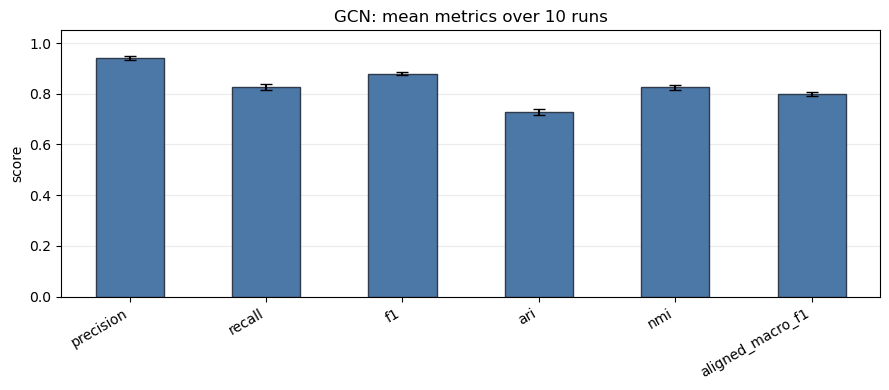

In [4]:
results = run_repeated_experiment(run_once, n_runs=N_RUNS, seed=SEED)
summary = summarize_metric_table(results)

display(results)
display(summary)
plot_metric_bars(summary, title=f'{METHOD_NAME}: mean metrics over {N_RUNS} runs')


## Assembly graph coloured by predicted bin

This plot reruns the method once on the original test graph using `SEED`, captures that method's KMeans bin assignments, and colours contigs in the igraph assembly graph by the predicted bin.

{'precision': 0.9430255402750491, 'recall': 0.8330058939096268, 'f1': 0.884608028930577, 'ari': 0.7329058051171096, 'nmi': 0.8296240362817469, 'n_bins_predicted': 5, 'n_true_bins': 5, 'aligned_macro_f1': 0.804444644225973, 'epochs': 390, 'loss': 1.0677132606506348}
GCN: assembly graph coloured by predicted bin
bin 0: 100 contigs
bin 1: 114 contigs
bin 2: 120 contigs
bin 3: 71 contigs
bin 4: 104 contigs


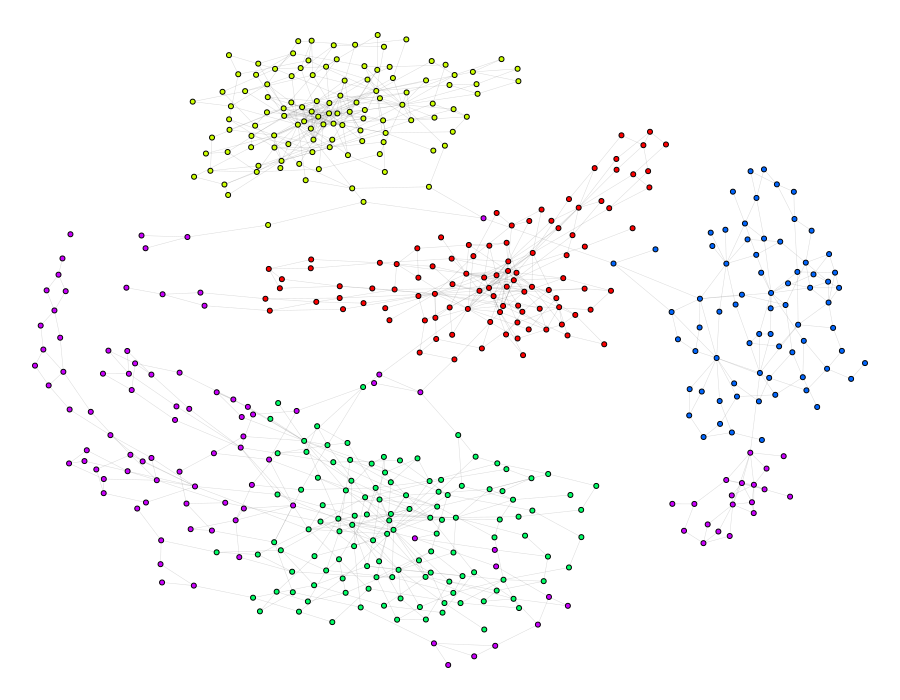

In [5]:
_visual_predictions = None
_original_run_kmeans = run_kmeans

def _capture_run_kmeans(embeddings, labels, seed=7, n_clusters=None):
    global _visual_predictions
    predictions, metrics = _original_run_kmeans(embeddings, labels, seed=seed, n_clusters=n_clusters)
    _visual_predictions = predictions
    return predictions, metrics

run_kmeans = _capture_run_kmeans
try:
    visual_metrics = run_once(SEED)
finally:
    run_kmeans = _original_run_kmeans

print(visual_metrics)
plot_assembly_graph_bins(
    data,
    bins=_visual_predictions,
    title=f'{METHOD_NAME}: assembly graph coloured by predicted bin',
)


## Graph corruption / ablation study

This section reruns the same method under five graph conditions: 

1. original assembly graph
2. random edge removal
3. random edge addition
4. coverage-similarity edges added
5. short contigs removed.

Each condition is run with the same 10 seeds, then metrics are summarized and plotted with standard-deviation error bars.

ablation: original assembly graph
ablation: random edge removal
ablation: random edge addition
ablation: coverage-similarity edges added
ablation: short contigs removed


,ablation,run,seed,precision,recall,f1,ari,nmi,n_bins_predicted,n_true_bins,aligned_macro_f1,epochs,loss
0,original assembly graph,1,7,0.948919,0.838900,0.890524,0.745300,0.839923,5,5,0.808613,384,1.067651
1,original assembly graph,2,8,0.948919,0.813360,0.875926,0.729426,0.837442,5,5,0.791992,400,1.067870
2,original assembly graph,3,9,0.943026,0.811395,0.872272,0.718518,0.822402,5,5,0.789460,387,1.067725
3,original assembly graph,4,10,0.925344,0.805501,0.861273,0.689769,0.796123,5,5,0.783758,312,1.067806
4,original assembly graph,5,11,0.927308,0.809430,0.864369,0.695129,0.799283,5,5,0.786489,313,1.067801
5,original assembly graph,6,12,0.927308,0.799607,0.858736,0.688112,0.801386,5,5,0.781124,369,1.067719
6,original assembly graph,7,13,0.931238,0.807466,0.864946,0.698642,0.807745,5,5,0.786541,288,1.067750
7,original assembly graph,8,14,0.935167,0.827112,0.877827,0.719112,0.817538,5,5,0.799508,344,1.067677
8,original assembly graph,9,15,0.927308,0.807466,0.863248,0.692883,0.801339,5,5,0.786225,374,1.067841
9,original assembly graph,10,16,0.944990,0.821218,0.878767,0.727260,0.825044,5,5,0.795699,380,1.067701


precision                                \
                                      min       max      mean       std   
ablation                                                                  
original assembly graph          0.925344  0.948919  0.935953  0.009589   
random edge removal              0.901768  0.921415  0.907269  0.005694   
random edge addition             0.888016  0.911591  0.897446  0.007339   
coverage-similarity edges added  0.833006  0.858546  0.844990  0.006896   
short contigs removed            0.904444  0.937778  0.919111  0.013505   

                                   recall                                \
                                      min       max      mean       std   
ablation                                                                  
original assembly graph          0.799607  0.838900  0.814145  0.011722   
random edge removal              0.777996  0.797642  0.785855  0.005857   
random edge addition             0.779961  0.803536  0.791356  0.007398   
coverage-similarity edges added  0.777996  0.827112  0.800589  0.013556   
short contigs removed            0.795556  0.824444  0.809778  0.012966   

                                       f1            ...       ari            \
                                      min       max  ...      mean       std   
ablation                                             ...                       
original assembly graph          0.858736  0.890524  ...  0.710415  0.020019   
random edge removal              0.835322  0.855073  ...  0.648128  0.012488   
random edge addition             0.832202  0.853049  ...  0.638925  0.013982   
coverage-similarity edges added  0.812720  0.835859  ...  0.587344  0.016047   
short contigs removed            0.847485  0.877467  ...  0.696064  0.027381   

                                      nmi                                \
                                      min       max      mean       std   
ablation                                                                  
original assembly graph          0.796123  0.839923  0.814822  0.016037   
random edge removal              0.751383  0.784701  0.760252  0.009490   
random edge addition             0.684995  0.735855  0.706972  0.014591   
coverage-similarity edges added  0.616780  0.644478  0.628545  0.010959   
short contigs removed            0.772243  0.823903  0.795070  0.019861   

                                aligned_macro_f1                                
                                             min       max      mean       std  
ablation                                                                        
original assembly graph                 0.781124  0.808613  0.790941  0.008307  
random edge removal                     0.764546  0.777890  0.769876  0.003890  
random edge addition                    0.755610  0.773789  0.763871  0.006152  
coverage-similarity edges added         0.726818  0.779959  0.748610  0.015228  
short contigs removed                   0.773817  0.795475  0.784194  0.009650  

[5 rows x 24 columns]

<Axes: title={'center': 'GCN: graph corruption / ablation study'}, xlabel='ablation', ylabel='score'>

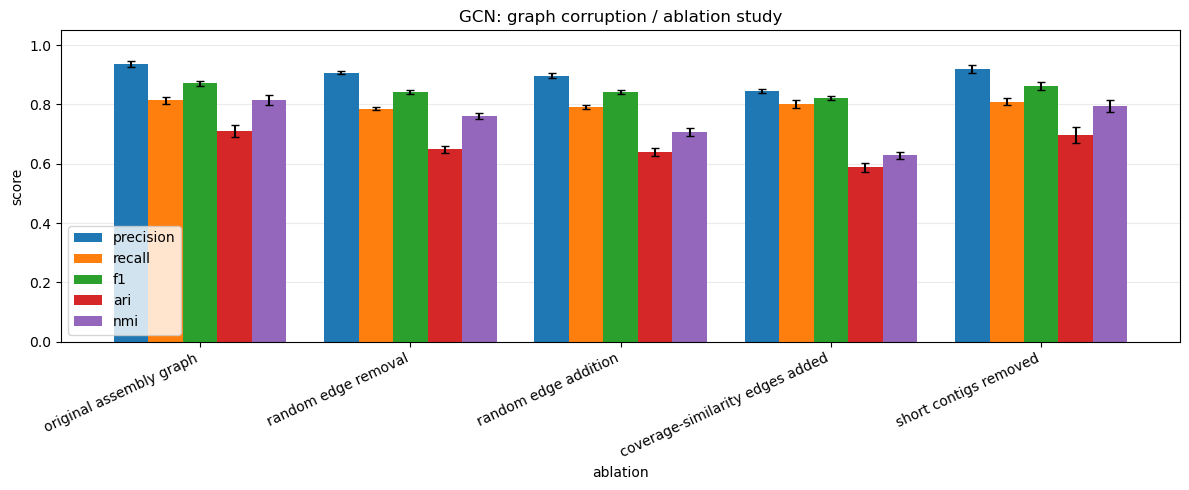

In [6]:
def run_once_ablation(seed, ablation_data):
    global features, adjacency, marker_pairs, labels, label_names, N_CLUSTERS, spectral_embeddings

    old_state = {
        'features': features,
        'adjacency': adjacency,
        'marker_pairs': marker_pairs,
        'labels': labels,
        'label_names': label_names,
        'N_CLUSTERS': N_CLUSTERS,
        'spectral_embeddings': globals().get('spectral_embeddings', None),
    }
    try:
        features = ablation_data['features']
        adjacency = ablation_data['adjacency']
        marker_pairs = ablation_data['marker_pairs']
        labels = ablation_data['labels']
        label_names = ablation_data['label_names']
        N_CLUSTERS = ablation_data['marker_cluster_count']

        # The Laplacian Eigenmaps notebook precomputes graph embeddings outside
        # run_once, so recompute them when the graph changes.
        if 'laplacian_eigenmap_embeddings' in globals():
            spectral_embeddings = laplacian_eigenmap_embeddings(adjacency, dimensions=32)

        return run_once(seed)
    finally:
        features = old_state['features']
        adjacency = old_state['adjacency']
        marker_pairs = old_state['marker_pairs']
        labels = old_state['labels']
        label_names = old_state['label_names']
        N_CLUSTERS = old_state['N_CLUSTERS']
        if old_state['spectral_embeddings'] is not None:
            spectral_embeddings = old_state['spectral_embeddings']

ablation_results, ablation_summary = run_graph_ablation_study(
    data,
    run_once_ablation,
    n_runs=N_RUNS,
    seed=SEED,
)

display(ablation_results)
display(ablation_summary)
plot_ablation_metric_bars(ablation_summary, title=f'{METHOD_NAME}: graph corruption / ablation study')
